In [2]:
# ESP32 Tiny Speech Command Classifier

import os, pathlib
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [3]:
# Paths
DATASET_PATH = "data"
commands = np.array(tf.io.gfile.listdir(str(DATASET_PATH)))
commands = commands[commands != "_background_noise_"]
print("Commands:", commands)

# Load and preprocess WAVs
def decode_audio(audio_binary):
    audio, _ = tf.audio.decode_wav(audio_binary)
    return tf.squeeze(audio, axis=-1)

def get_label(file_path):
    parts = tf.strings.split(file_path, os.path.sep)
    return parts[-2]

def preprocess(file_path):
    label = get_label(file_path)
    audio_binary = tf.io.read_file(file_path)
    waveform = decode_audio(audio_binary)
    # Pad/trim to 1 sec
    waveform = waveform[:16000]
    zero_padding = tf.zeros([16000] - tf.shape(waveform), dtype=tf.float32)
    waveform = tf.concat([waveform, zero_padding], 0)
    return waveform, label

# Load file paths
filenames = tf.io.gfile.glob(str(DATASET_PATH) + '/*/*.wav')
waveforms = []
labels = []
for f in filenames[:300]:  # small subset
    w, l = preprocess(f)
    waveforms.append(w)
    labels.append(l.numpy().decode())

label_names = sorted(set(labels))
label_to_index = {name: i for i, name in enumerate(label_names)}
print("Labels:", label_to_index)

waveforms = np.array([w.numpy() for w in waveforms])
labels = np.array([label_to_index[l] for l in labels])

# Convert to MFCCs
def get_spectrogram(waveform):
    spectrogram = tf.signal.stft(waveform, frame_length=255, frame_step=128)
    spectrogram = tf.abs(spectrogram)
    return spectrogram

spectrograms = np.array([get_spectrogram(w) for w in waveforms])
spectrograms = spectrograms[..., np.newaxis]

X_train, X_test, y_train, y_test = train_test_split(spectrograms, labels, test_size=0.2, random_state=42)

# Build Tiny CNN
model = tf.keras.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Conv2D(8, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(16, activation='relu'),
    layers.Dense(len(label_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=15, batch_size=16,
                    validation_data=(X_test, y_test))

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"Accuracy: {acc*100:.2f}%")

Commands: ['no' 'yes']
Labels: {'_background_noise_': 0, 'no': 1, 'yes': 2}
Epoch 1/15
11/11 [==============================] - 8s 49ms/step - loss: 0.8362 - accuracy: 0.7500 - val_loss: 0.4827 - val_accuracy: 0.9048
Epoch 2/15
11/11 [==============================] - 0s 17ms/step - loss: 0.2957 - accuracy: 0.9390 - val_loss: 0.3483 - val_accuracy: 0.8571
Epoch 3/15
11/11 [==============================] - 0s 17ms/step - loss: 0.1321 - accuracy: 0.9512 - val_loss: 0.4305 - val_accuracy: 0.8571
Epoch 4/15
11/11 [==============================] - 0s 20ms/step - loss: 0.0869 - accuracy: 0.9634 - val_loss: 0.4295 - val_accuracy: 0.8810
Epoch 5/15
11/11 [==============================] - 0s 14ms/step - loss: 0.0585 - accuracy: 0.9878 - val_loss: 0.5167 - val_accuracy: 0.7857
Epoch 6/15
11/11 [==============================] - 0s 23ms/step - loss: 0.0417 - accuracy: 1.0000 - val_loss: 0.4925 - val_accuracy: 0.8810
Epoch 7/15
11/11 [==============================] - 0s 16ms/step - loss: 0.030

INFO:tensorflow:Assets written to: C:\Users\kukil\AppData\Local\Temp\tmp5w4je8h8\assets


INFO:tensorflow:Assets written to: C:\Users\kukil\AppData\Local\Temp\tmp5w4je8h8\assets


Saved speech_esp32.tflite
✅ model.h ready for Arduino


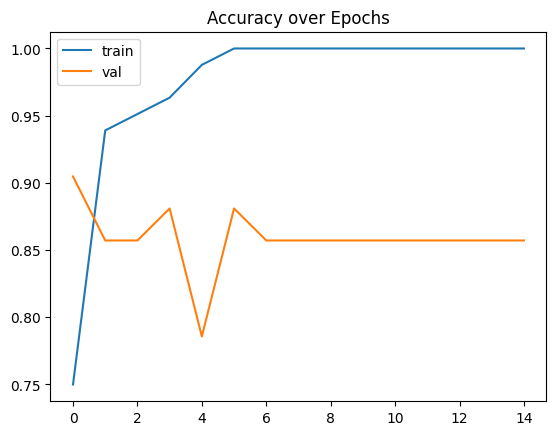

In [4]:
# Quantize to TFLite
def representative_dataset():
    for i in range(100):
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

with open("speech_esp32.tflite", "wb") as f:
    f.write(tflite_model)
print("Saved speech_esp32.tflite")

# Convert to C Array
def convert_to_c_array(tflite_model):
    hex_data = ', '.join(['0x{:02x}'.format(x) for x in tflite_model])
    c_array = f"const unsigned char model_tflite[] = {{{hex_data}}};\nconst int model_tflite_len = {len(tflite_model)};"
    with open("model.h", "w") as f:
        f.write(c_array)
    print("✅ model.h ready for Arduino")

convert_to_c_array(tflite_model)

# Plot Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend(), plt.title("Accuracy over Epochs")
plt.show()